In [44]:
# Imports and setup
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Try to import matsim; if local matsim-py exists, add it to sys.path
import matsim


print('pandas', pd.__version__)
print('matsim', getattr(matsim, '__version__', 'local'))

pandas 2.3.0
matsim local


In [45]:
# Define MATSim output paths (adjust if needed)
# Scenario: Hannover base case without freight (persons only)
from pathlib import Path
base = Path('c:/Users/bienzeisler/Documents/GitHub/HAGRID/parcel-analysis/input/simRes/Hannover_BC_not_freight')
scenario_name = 'hanover-v1.0-10pct-calibration'

network_path = base / f'{scenario_name}.output_network.xml.gz'
events_path = base / f'{scenario_name}.output_events.xml.gz'

print('Network:', network_path)
print('Events :', events_path)
assert network_path.exists(), f"Missing network file: {network_path}"
assert events_path.exists(), f"Missing events file: {events_path}"

Network: c:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\Hannover_BC_not_freight\hanover-v1.0-10pct-calibration.output_network.xml.gz
Events : c:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\Hannover_BC_not_freight\hanover-v1.0-10pct-calibration.output_events.xml.gz


               x             y     node_id
0  597795.215238  5.643788e+06  1000027858
1  597964.938950  5.643792e+06  1000027902
2  597804.407341  5.644050e+06  1000027910
3  597813.461633  5.644024e+06  1000027919
4  597876.430109  5.644122e+06  1000027941
       length  freespeed  capacity  permlanes oneway         modes  \
0   23.253445  13.888889     600.0        1.0      1      car,ride   
1   82.447653  13.888889     600.0        1.0      1      car,ride   
2    9.382632  13.888889     600.0        1.0      1      car,ride   
3  284.766738   6.944444     600.0        1.0      1  car,ride,bus   
4  142.843917   8.333333     600.0        1.0      1      car,ride   

           link_id   from_node     to_node  
0                1   433025851   433025853  
1               10   259943712   259943704  
2             1000  4664222487  5394377687  
3           100000   250352077   250351215  
4  1000000-3257059  4570556386  1945144117  


Text(0.5, 1.0, 'Network geometry (links)')

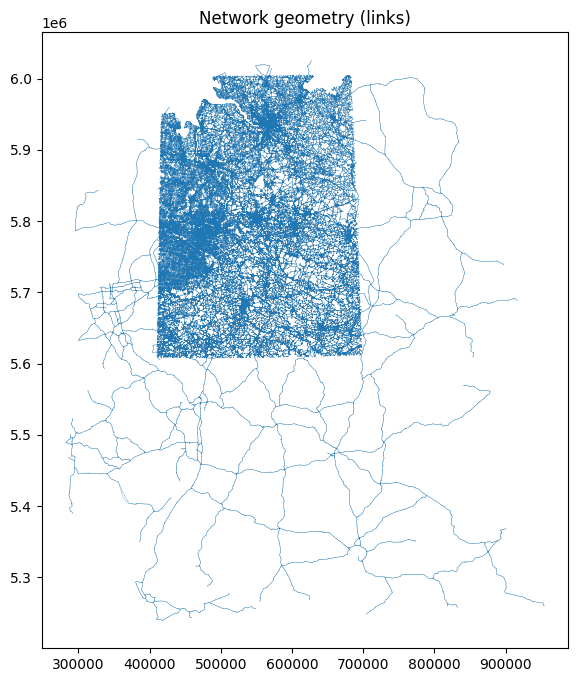

In [ ]:
# 1) Read network and build geometries
net = matsim.read_network(str(network_path))
print(net.nodes.head())
print(net.links.head())

# Build GeoDataFrame and plot network
geo = net.as_geo()
ax = geo.plot(figsize=(8,8), linewidth=0.2)
ax.set_title('Network geometry (links)')

In [47]:
# 2) Stream events to compute hourly volumes and utilization
from collections import defaultdict
from tqdm import tqdm

# Read only entered/left link events
reader = matsim.event_reader(str(events_path), types='entered link,left link')

# Since this is a 10% sample, scale volumes by 10
SCALING_FACTOR = 10

# Buckets: (link_id, hour) -> count of entries (unscaled)
per_hour_counts = defaultdict(int)

for i, ev in enumerate(tqdm(reader, desc='Reading events', unit='ev')):
    if ev['type'] == 'entered link':
        # time is seconds; convert to hour-of-day (0..23)
        hour = int(ev['time'] // 3600)
        per_hour_counts[(ev['link'], hour)] += 1

# DataFrame: link_id, hour, count (scaled by sample factor)
hourly = (
    pd.DataFrame(
        [
            {'link_id': k[0], 'hour': k[1], 'count': v}
            for k, v in per_hour_counts.items()
        ]
    )
    .sort_values(['link_id', 'hour'])
)

# Apply scaling for 10% sample
hourly['count'] = hourly['count'] * SCALING_FACTOR

# Attach link capacity and free speed etc. from net.links
links_df = net.links[['link_id', 'capacity', 'length', 'freespeed', 'from_node', 'to_node']].copy()

hourly = hourly.merge(links_df, on='link_id', how='left')

# Utilization proxy: volume per hour vs capacity (capacity is per hour in MATSim by default)
hourly['utilization'] = np.where(hourly['capacity'] > 0, hourly['count'] / hourly['capacity'], np.nan)

print(f'Applied scaling factor = {SCALING_FACTOR}')
print(hourly.head())

Reading events: 32780178ev [01:43, 317952.75ev/s]



Applied scaling factor = 10
  link_id  hour  count  capacity      length  freespeed   from_node  \
0    1000    24     10     600.0    9.382632  13.888889  4664222487   
1  100000     4     20     600.0  284.766738   6.944444   250352077   
2  100000     5     80     600.0  284.766738   6.944444   250352077   
3  100000     6    160     600.0  284.766738   6.944444   250352077   
4  100000     7    230     600.0  284.766738   6.944444   250352077   

      to_node  utilization  
0  5394377687     0.016667  
1   250351215     0.033333  
2   250351215     0.133333  
3   250351215     0.266667  
4   250351215     0.383333  


In [ ]:
# 2b) Merge hourly volumes/utilization with GeoDataFrame and helpers
geo_links = geo.copy()
# Ensure we have a link identifier column named 'link_id'
key_col = 'link_id' if 'link_id' in geo_links.columns else ('id' if 'id' in geo_links.columns else None)
if key_col is None:
    raise KeyError('GeoDataFrame has no link id column (expected link_id or id). Columns: ' + ','.join(geo_links.columns))
if key_col != 'link_id':
    geo_links = geo_links.rename(columns={key_col: 'link_id'})

# Align dtypes for robust join
geo_links['link_id'] = geo_links['link_id'].astype(str)
hourly['link_id'] = hourly['link_id'].astype(str)

def build_hour_map_df(hour:int, metric:str='count'):
    """Return a GeoDataFrame for given hour with the chosen metric merged on links.
    metric in {'count','utilization'}
    """
    subset = hourly[hourly['hour'] == int(hour)][['link_id','count','utilization']]
    gdf = geo_links.merge(subset, on='link_id', how='left')
    # Fill missing metric values for links without events in that hour
    gdf['count'] = gdf['count'].fillna(0)
    return gdf

def plot_hour_map(hour:int, metric:str='count', cmap:str='Wistia', figsize=(9,9)):
    gdf = build_hour_map_df(hour, metric)
    col = metric if metric in gdf.columns else 'count'
    ax = gdf.plot(column=col, figsize=figsize, cmap=cmap, legend=True, linewidth=0.4)
    ax.set_title(f'{col} on network — hour={int(hour)}')
    return ax

In [ ]:
# 2d) Restrict to links also present in a freight network
from pathlib import Path

# Try known candidates; adjust to your actual freight scenario if needed
freight_candidates = [
    # Path('c:/Users/bienzeisler/Documents/GitHub/HAGRID/parcel-analysis/input/simRes/BC_500_it_no_reduction/basecase_13052025.output_network.xml.gz'),
    # Path('c:/Users/bienzeisler/Documents/GitHub/HAGRID/parcel-analysis/input/simRes/500-it/basecase_13052025/basecase_13052025.output_network.xml.gz'),
    Path('c:/Users/bienzeisler/Documents/GitHub/HAGRID/parcel-analysis/input/simRes/basecase_13052025/basecase_13052025.output_network.xml.gz'),
]
freight_network_path = next((p for p in freight_candidates if p.exists()), None)

if freight_network_path is None:
    raise FileNotFoundError('No freight network found. Set freight_network_path to your freight output_network.xml.gz')

print('Using freight network:', freight_network_path)
freight_geo = matsim.read_network(str(freight_network_path)).as_geo()
if 'link_id' not in freight_geo.columns and 'id' in freight_geo.columns:
    freight_geo = freight_geo.rename(columns={'id':'link_id'})
freight_geo['link_id'] = freight_geo['link_id'].astype(str)

# Compute intersection and restrict
allow = set(freight_geo['link_id'].unique())
print('Freight links:', len(allow), '| Base links:', len(geo_links), end=' ')

geo_links = geo_links[geo_links['link_id'].isin(allow)].copy()
print('| Kept base links:', len(geo_links))

# Also restrict hourly metrics to common links
hourly = hourly[hourly['link_id'].astype(str).isin(allow)].copy()

Using freight network: c:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\basecase_13052025\basecase_13052025.output_network.xml.gz
Freight links: 544514 | Base links: 2121528 Freight links: 544514 | Base links: 2121528 | Kept base links: 544514
| Kept base links: 544514


In [50]:
# 2c) Helpers to plot high-utilization links on a map

def plot_hot_links_by_hour(hour:int, util_threshold:float=0.8, top_n:int|None=None,
                           base_color:str='#E0E0E0', cmap:str='Reds', figsize=(10,10)):
    sub = hourly[hourly['hour'] == int(hour)].copy()
    sub = sub.dropna(subset=['utilization'])
    if util_threshold is not None:
        sub = sub[sub['utilization'] >= float(util_threshold)]
    if top_n is not None:
        sub = sub.sort_values('utilization', ascending=False).head(int(top_n))
    # Keep only links to draw
    sel = geo_links.merge(sub[['link_id','utilization','count']], on='link_id', how='inner')
    ax = geo_links.plot(color=base_color, linewidth=0.2, figsize=figsize)
    sel.plot(column='utilization', cmap=cmap, linewidth=1.2, legend=True, ax=ax)
    ax.set_title(f'Links with utilization >= {util_threshold} — hour {int(hour)}')
    return ax


def plot_hot_links_peak(util_threshold:float=0.8, top_n:int|None=None,
                        base_color:str='#E0E0E0', cmap:str='Reds', figsize=(10,10)):
    peak = hourly.groupby('link_id', as_index=False)['utilization'].max()
    peak = peak.dropna(subset=['utilization'])
    if util_threshold is not None:
        peak = peak[peak['utilization'] >= float(util_threshold)]
    if top_n is not None:
        peak = peak.sort_values('utilization', ascending=False).head(int(top_n))
    sel = geo_links.merge(peak[['link_id','utilization']], on='link_id', how='inner')
    ax = geo_links.plot(color=base_color, linewidth=0.2, figsize=figsize)
    sel.plot(column='utilization', cmap=cmap, linewidth=1.2, legend=True, ax=ax)
    ax.set_title(f'Links with peak utilization >= {util_threshold} (any hour)')
    return ax

In [51]:
hourly[hourly['utilization'] > 0.8].sort_values('utilization', ascending=False)

,link_id,hour,count,capacity,length,freespeed,from_node,to_node,utilization
1365716,2493847,7,500,300.0,27.220158,2.777778,332545185,257832125,1.666667
334258,1357111,7,490,300.0,27.123253,2.777778,257832141,278298190,1.633333
1083689,2183143,7,490,300.0,107.311021,2.777778,257832125,257832141,1.633333
1083677,2183142,16,470,300.0,107.311021,2.777778,257832141,257832125,1.566667
1083674,2183142,13,470,300.0,107.311021,2.777778,257832141,257832125,1.566667
...,...,...,...,...,...,...,...,...,...
2570346,3820359-2744206-119767-3274682-3003837,7,2410,3000.0,872.286305,13.888889,33327472,302624550,0.803333
347335,1370584,13,2410,3000.0,5.000000,13.888889,9555091467,9555091468,0.803333
186831,120323,7,2410,3000.0,42.605847,13.888889,279176947,21478205,0.803333
3020411,854114,16,2410,3000.0,16.867718,19.444444,266572201,32932786,0.803333


Using busiest hour: 8


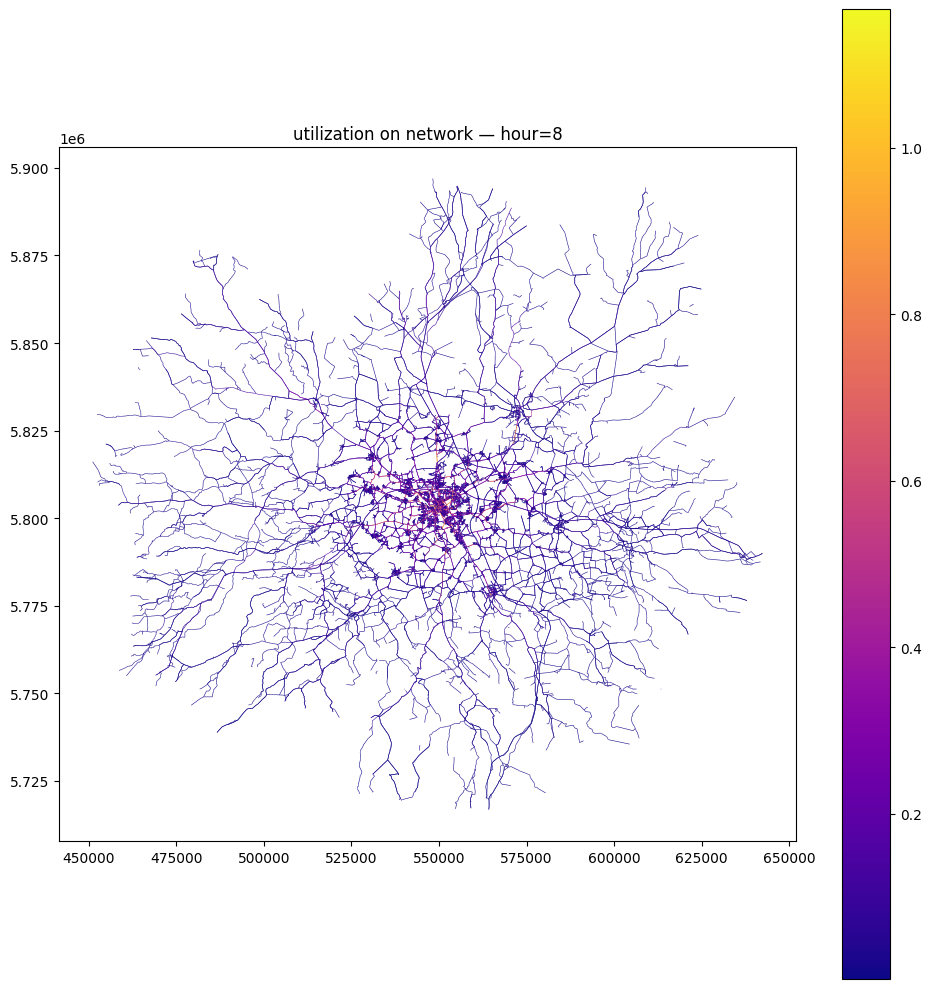

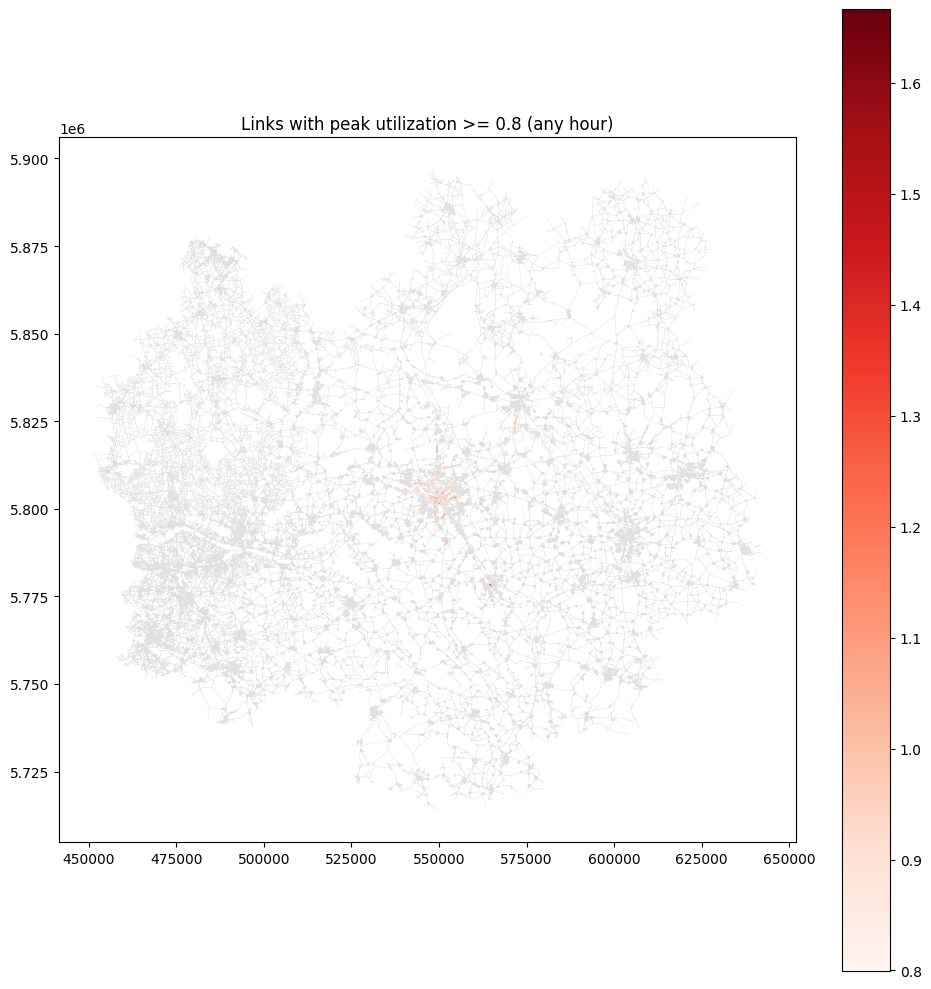

In [52]:
# 3) Map trio: count (hour), utilization (hour), and peak hot links
hour_to_plot = int(hourly.groupby('hour')['count'].sum().idxmax())
print(f'Using busiest hour: {hour_to_plot}')

# Count map (busiest hour)
# ax = plot_hour_map(hour_to_plot, metric='count', cmap='Wistia', figsize=(10,10))
# plt.tight_layout()

# Utilization map (busiest hour)
ax = plot_hour_map(hour_to_plot, metric='utilization', cmap='plasma', figsize=(10,10))
plt.tight_layout()

# Peak hot links across the day (any hour >= threshold)
ax = plot_hot_links_peak(util_threshold=0.8, top_n=None, cmap='Reds', figsize=(10,10))
plt.tight_layout()

In [57]:
# Helper: plot weighted lines (hide zeros, scale width by value)
import numpy as np
import matplotlib.pyplot as plt

def plot_weighted_lines(base_gdf, overlay_gdf, value_col: str,
                        cmap: str = 'magma', base_color: str = '#E0E0E0',
                        min_lw: float = 0.6, max_lw: float = 2.5,
                        figsize=(10,10), title: str | None = None, legend: bool = True,
                        crop_to_overlay: bool = False, buffer_ratio: float = 0.05):
    ax = base_gdf.plot(color=base_color, linewidth=0.2, figsize=figsize)
    if overlay_gdf is None or value_col not in overlay_gdf.columns:
        if title:
            ax.set_title(title + ' (no data)')
        return ax
    ov = overlay_gdf.dropna(subset=[value_col]).copy()
    ov = ov[ov[value_col] > 0]
    if ov.empty:
        if title:
            ax.set_title(title + ' (no nonzero values)')
        return ax
    n_before = len(ax.collections)
    ax2 = ov.plot(column=value_col, cmap=cmap, linewidth=1.0, legend=legend, ax=ax)
    # Adjust per-feature linewidths on the newly added LineCollection
    new_cols = ax2.collections[n_before:]
    if new_cols:
        coll = new_cols[0]
        vals = ov[value_col].to_numpy(dtype=float)
        vmin = 0.0
        vmax = float(np.nanmax(vals)) if np.isfinite(vals).any() else 1.0
        if vmax <= vmin:
            widths = np.full_like(vals, min_lw, dtype=float)
        else:
            widths = min_lw + (vals - vmin) / (vmax - vmin) * (max_lw - min_lw)
        coll.set_linewidths(widths)

    # Optionally crop to overlay bounds with a buffer
    if crop_to_overlay:
        try:
            minx, miny, maxx, maxy = ov.total_bounds
            dx = (maxx - minx)
            dy = (maxy - miny)
            if dx == 0:
                dx = 1.0
            if dy == 0:
                dy = 1.0
            bx = dx * float(buffer_ratio)
            by = dy * float(buffer_ratio)
            ax.set_xlim(minx - bx, maxx + bx)
            ax.set_ylim(miny - by, maxy + by)
        except Exception:
            pass

    if title:
        ax.set_title(title)
    return ax

Using freight events: c:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\basecase_13052025\basecase_13052025.output_events.xml.gz


Parsing LMD service stops: 0ev [00:00, ?ev/s]

Parsing LMD service stops: 190410ev [00:07, 25962.84ev/s]



Extracted LMD stops: 92906


,link_id,hour,count,capacity,length,freespeed,from_node,to_node,utilization,stops,dwell_avg_s,risk_score
0,100000,4,20,600.0,284.766738,6.944444,250352077,250351215,0.033333,0.0,0.0,0.003333
1,100000,5,80,600.0,284.766738,6.944444,250352077,250351215,0.133333,0.0,0.0,0.013333
2,100000,6,160,600.0,284.766738,6.944444,250352077,250351215,0.266667,0.0,0.0,0.026667
3,100000,7,230,600.0,284.766738,6.944444,250352077,250351215,0.383333,0.0,0.0,0.038333
4,100000,8,190,600.0,284.766738,6.944444,250352077,250351215,0.316667,1.0,121.0,0.488828


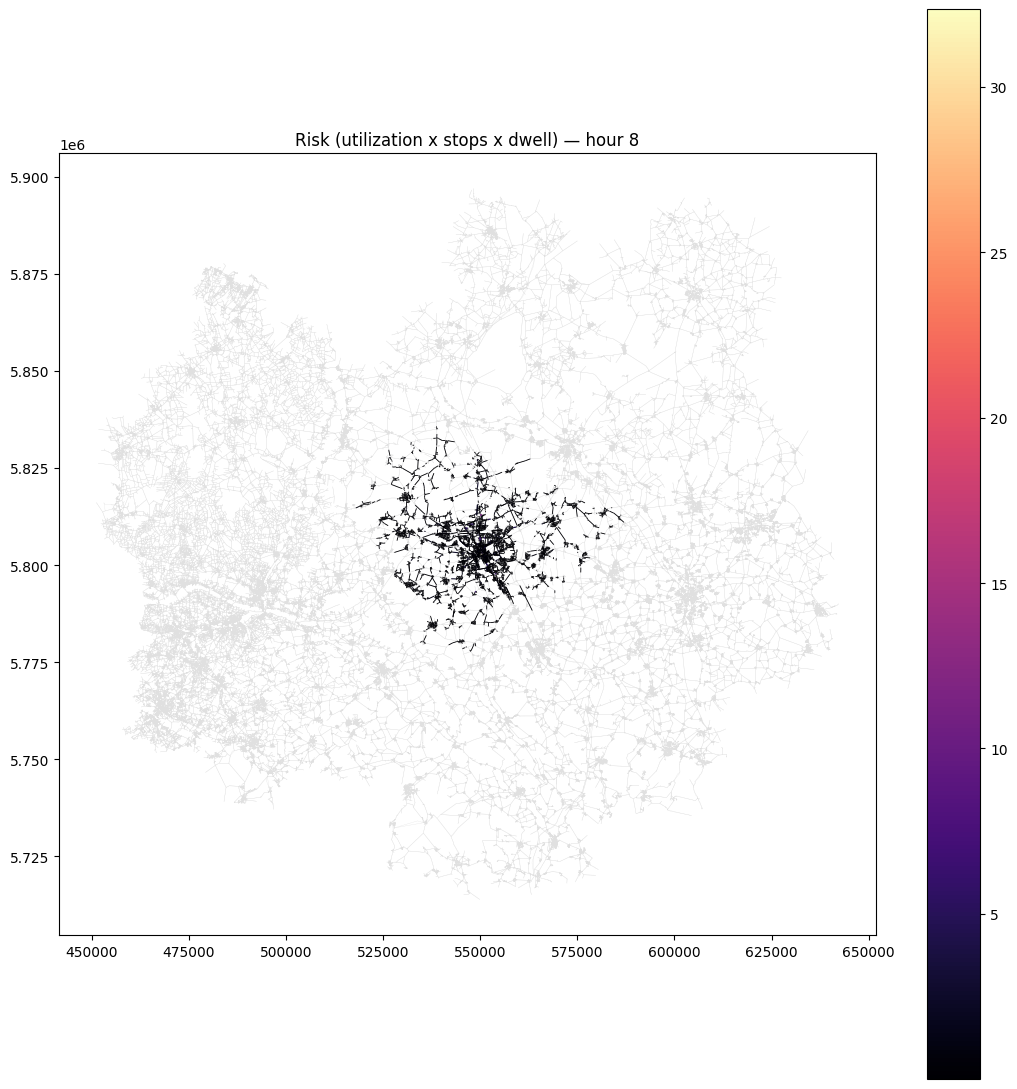

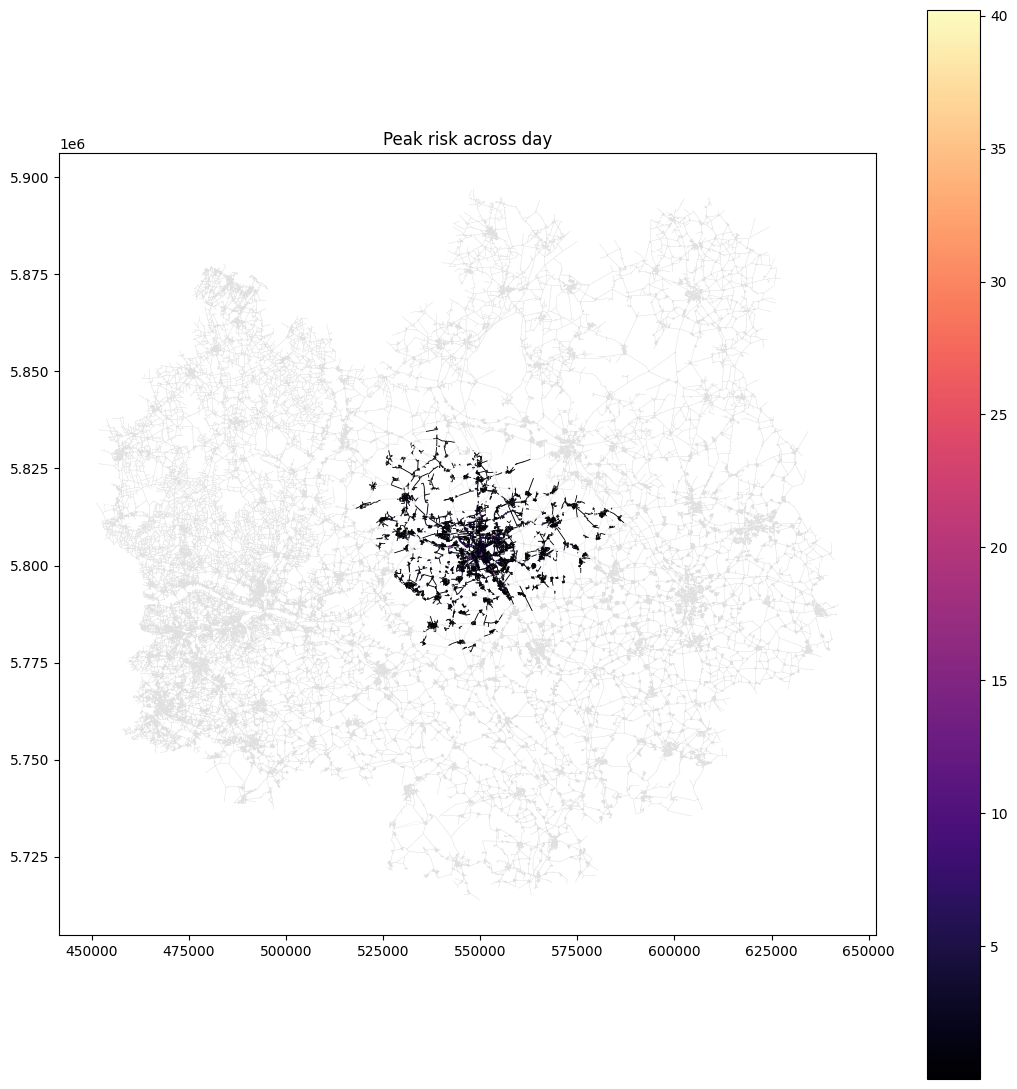

In [ ]:
# 4) Derive LMD service stops from events and compute risk
# We avoid stopwatch CSV (simulation runtime) and extract stops from actstart/actend events instead.
# Inputs:
# - freight_events_path (candidates below) to read LMD service activities
# - hourly (per-link volumes/utilization from base scenario, already computed)

from collections import defaultdict
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import numpy as np

# 4a) Pick freight events file
freight_event_candidates = [
    Path('c:/Users/bienzeisler/Documents/GitHub/HAGRID/parcel-analysis/input/simRes/basecase_13052025/basecase_13052025.output_events.xml.gz')
]
freight_events_path = next((p for p in freight_event_candidates if p.exists()), None)
if freight_events_path is None:
    raise FileNotFoundError('No freight events found. Set freight_events_path to your freight output_events.xml.gz')
print('Using freight events:', freight_events_path)

# 4b) Extract LMD service stops from events
LMD_PATTERNS = ['_CEP_Vehicle_', '_veh_cep_', '_egrocery_van_', '_cargoBike_', '_cargobike_']
SUPPLY_PATTERNS = ['_Supply_Vehicle_', '_veh_supply_']

def is_lmd(person: str) -> bool:
    if person is None:
        return False
    s = str(person)
    if any(p in s for p in SUPPLY_PATTERNS):
        return False
    return any(p in s for p in LMD_PATTERNS)

open_service = {}  # person -> (start_time, link)
stop_records = []

reader = matsim.event_reader(str(freight_events_path), types='actstart,actend')
for ev in tqdm(reader, desc='Parsing LMD service stops', unit='ev'):
    t = ev.get('time')
    if t is None:
        continue
    # constrain to 0..24h for day-level view
    hour = int(t // 3600)
    if hour < 0 or hour >= 24:
        continue

    if ev.get('actType') == 'service' and is_lmd(ev.get('person')):
        if ev['type'] == 'actstart':
            if ev.get('link') is None:
                continue
            open_service[ev['person']] = (t, str(ev.get('link')))
        elif ev['type'] == 'actend':
            if ev['person'] in open_service:
                t0, link_id = open_service.pop(ev['person'])
                duration = max(0.0, float(t) - float(t0))
                stop_records.append({
                    'person': ev['person'],
                    'link_id': str(link_id),
                    'start_time': float(t0),
                    'end_time': float(t),
                    'duration_s': duration,
                })

stops_df = pd.DataFrame(stop_records)
print(f'Extracted LMD stops: {len(stops_df)}')

# 4c) Aggregate stops per link per hour
if not stops_df.empty:
    stops_df['hour'] = (stops_df['start_time'] // 3600).astype(int)
    stops_df = stops_df[(stops_df['hour'] >= 0) & (stops_df['hour'] < 24)]
    link_hour_stops = (
        stops_df.groupby(['link_id','hour'])
        .agg(stops=('person','count'), dwell_avg_s=('duration_s','mean'))
        .reset_index()
    )
    # Links with at least one LMD stop during the day
    LMD_LINKS_DAY = set(stops_df['link_id'].astype(str).unique())
else:
    # ensure downstream code works even if no stops
    link_hour_stops = pd.DataFrame(columns=['link_id','hour','stops','dwell_avg_s'])
    LMD_LINKS_DAY = set()

# 4d) Join with hourly utilization and compute heuristic risk score
risk = hourly.merge(link_hour_stops, on=['link_id','hour'], how='left')
risk['stops'] = risk['stops'].fillna(0)
risk['dwell_avg_s'] = risk['dwell_avg_s'].fillna(0)

# Heuristic risk score: utilization-weighted stop intensity and dwell
risk['risk_score'] = (
    risk['utilization'].clip(0, 2.0) * (risk['stops'] + 0.1) * (1 + risk['dwell_avg_s'] / 300.0)
)

# 4e) Map: show risk at busiest hour and peak risk across day (hide zeros, variable width)
hour_to_plot = int(hourly.groupby('hour')['count'].sum().idxmax())
risk_hour_map = geo_links.merge(risk[risk['hour']==hour_to_plot][['link_id','risk_score']], on='link_id', how='left')
risk_hour_map['risk_score'] = risk_hour_map['risk_score'].fillna(0)
# Filter to links that have at least one LMD stop during the day
if LMD_LINKS_DAY:
    risk_hour_map = risk_hour_map[risk_hour_map['link_id'].isin(LMD_LINKS_DAY)]
plot_weighted_lines(geo_links, risk_hour_map, 'risk_score', cmap='magma',
                    min_lw=0.6, max_lw=3.0, figsize=(11,11),
                    title=f'Risk (utilization x stops x dwell) — hour {hour_to_plot}', legend=True)
plt.tight_layout()

peak_risk = (
    risk.groupby('link_id', as_index=False)['risk_score'].max()
    .rename(columns={'risk_score':'risk_peak'})
)
peak_map = geo_links.merge(peak_risk, on='link_id', how='left')
peak_map['risk_peak'] = peak_map['risk_peak'].fillna(0)
if LMD_LINKS_DAY:
    peak_map = peak_map[peak_map['link_id'].isin(LMD_LINKS_DAY)]
plot_weighted_lines(geo_links, peak_map, 'risk_peak', cmap='magma',
                    min_lw=0.6, max_lw=3.0, figsize=(11,11),
                    title='Peak risk across day', legend=True)
plt.tight_layout()

# Expose for further analysis
risk.head()

,link_id,hour,count,capacity,length,freespeed,from_node,to_node,utilization,stops,dwell_avg_s,risk_score,rho,p_over,p_traffic,permlanes,lane_factor,p_second_row
777391,2392075,8,570,600.0,162.683048,8.333333,269916971,369106617,0.950000,2.0,1481.000000,11.843650,0.822778,0.560790,0.817574,1.0,1.0,0.458488
1073923,2912552-2912554,10,500,600.0,259.236612,6.944444,50806446,1393946445,0.833333,3.0,1848.000000,18.496667,1.540000,0.785619,0.582570,1.0,1.0,0.457678
535476,1934770-310872,12,570,600.0,144.129032,13.888889,25808247,25805863,0.950000,1.0,2726.000000,10.540567,0.757222,0.531033,0.817574,1.0,1.0,0.434159
339115,1574887-382021,12,680,600.0,133.827932,13.888889,1476775395,1476775416,1.133333,4.0,493.250000,12.286561,0.548056,0.421927,0.965555,1.0,1.0,0.407394
1758171,698990,9,550,600.0,52.646348,4.166667,34042715,260564783,0.916667,3.0,764.333333,10.081602,0.636944,0.471094,0.762542,1.0,1.0,0.359229
1775061,728115-1638039-2495032,15,550,600.0,410.777331,13.888889,33202972,1749551144,0.916667,2.0,1062.500000,8.742708,0.590278,0.445827,0.762542,1.0,1.0,0.339962
1867579,902319,13,490,600.0,182.541211,5.555556,9592415278,260566620,0.816667,3.0,1155.000000,12.278583,0.962500,0.618063,0.541570,1.0,1.0,0.334725
1755340,694591-694593-1101568-3043857,13,460,600.0,481.337724,13.888889,33931591,136805301,0.766667,3.0,1926.333333,17.637507,1.605278,0.799166,0.417430,1.0,1.0,0.333596
535478,1934770-310872,14,610,600.0,144.129032,13.888889,25808247,25805863,1.016667,2.0,802.500000,7.846125,0.445833,0.359710,0.897216,1.0,1.0,0.322737
1867582,902319,16,520,600.0,182.541211,5.555556,9592415278,260566620,0.866667,1.0,2385.000000,8.532333,0.662500,0.484439,0.660756,1.0,1.0,0.320096


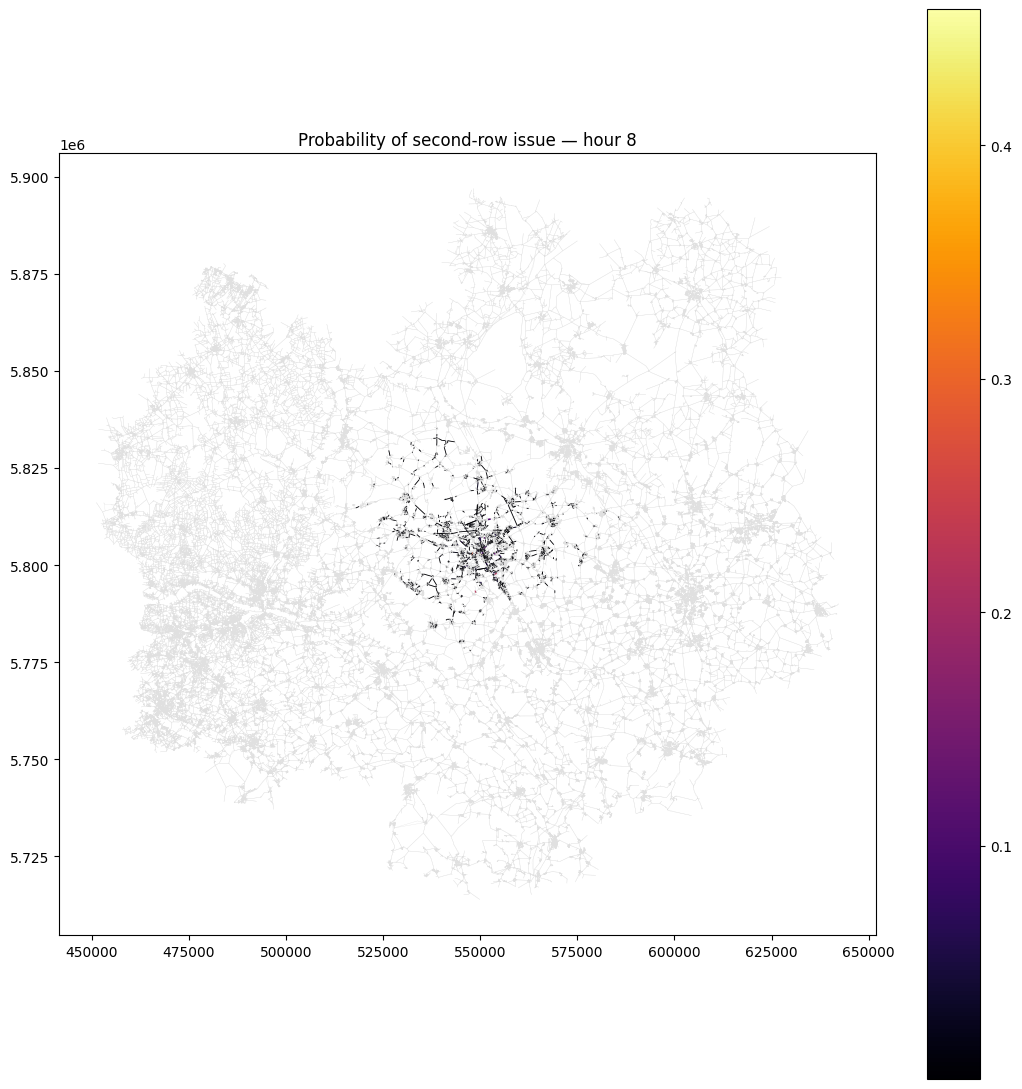

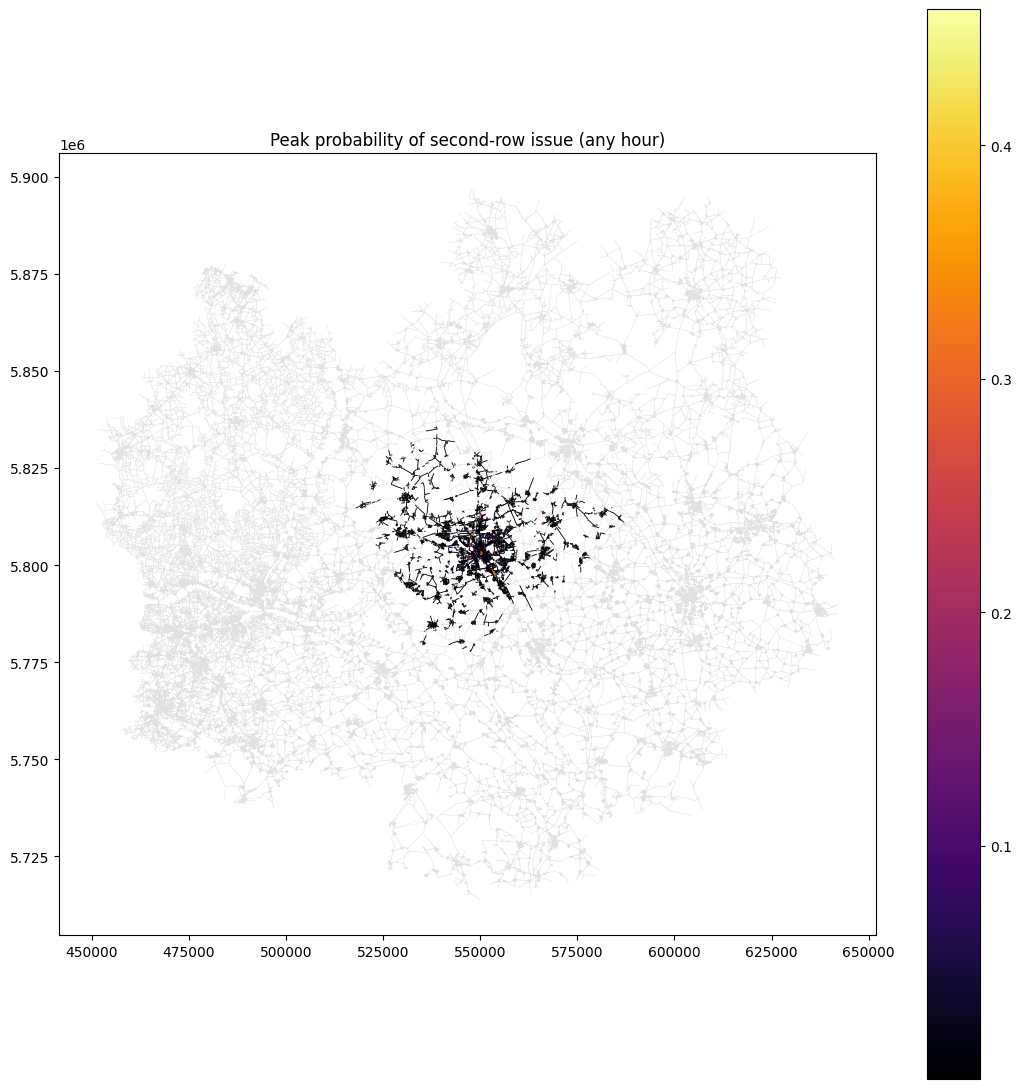

In [ ]:
# 4a) Probability model: second-row risk as occupancy exceedance x traffic pressure
# Assumptions:
# - Stops arrive ~ Poisson with rate lambda = stops/hour (from events-derived LMD stops)
# - Dwell times ~ general; number of concurrent parked vehicles on a link is Poisson with mean rho = lambda * E[dwell]/3600
# - With B legal bays on/near the link, the probability demand exceeds B is P_over = 1 - PoiCDF(B; rho)
# - Combine with traffic pressure p_traffic = sigmoid(alpha*(utilization - u0)) to focus on high-utilization periods
# - Adjust for lane count: more lanes -> lower probability (lane_factor = 1 / lanes^LANE_ALPHA)

from scipy.stats import poisson

# Parameters (tuneable)
B_BAYS_DEFAULT = 0   # assume no dedicated loading bay; set 1 or 2 if known
U0 = 0.8             # utilization inflection
ALPHA = 10.0         # steepness of traffic pressure
LANE_ALPHA = 1.0     # reduction strength with lanes (1/lanes^LANE_ALPHA)

# Scenario toggle: assume always double parking (no legal bays available)
ALWAYS_DOUBLE_PARKING = True
B_EFFECTIVE = 0 if ALWAYS_DOUBLE_PARKING else B_BAYS_DEFAULT

# Build per-link-hour frame with stop stats already merged in prior cell
if not {'stops','dwell_avg_s'}.issubset(risk.columns):
    # merge if needed (e.g., if cell was run alone)
    risk = hourly.merge(link_hour_stops, on=['link_id','hour'], how='left')
    risk['stops'] = risk['stops'].fillna(0)
    risk['dwell_avg_s'] = risk['dwell_avg_s'].fillna(0)

# Compute occupancy mean rho and exceedance probability
risk['rho'] = (risk['stops'].astype(float) * risk['dwell_avg_s'].astype(float)) / 3600.0
risk['p_over'] = 1.0 - poisson.cdf(B_EFFECTIVE, risk['rho'])

# Traffic pressure weight
risk['p_traffic'] = 1.0 / (1.0 + np.exp(-ALPHA * (risk['utilization'] - U0)))

# Lane factor: fetch lanes from risk or merge from network; default to 1
lane_col = None
for c in ['permlanes','lanes','num_lanes']:
    if c in risk.columns:
        lane_col = c
        break
if lane_col is None and hasattr(net, 'links'):
    # try to merge lanes from network table
    for c in ['permlanes','lanes','num_lanes']:
        if c in net.links.columns:
            lanes_df = net.links[['link_id', c]].copy()
            lanes_df['link_id'] = lanes_df['link_id'].astype(str)
            risk = risk.merge(lanes_df, on='link_id', how='left')
            lane_col = c
            break

if lane_col is None:
    risk['lanes'] = 1.0
    lane_col = 'lanes'

# sanitize lanes
risk[lane_col] = pd.to_numeric(risk[lane_col], errors='coerce').fillna(1.0)
risk[lane_col] = risk[lane_col].clip(lower=1.0, upper=8.0)

# Lane reduction factor (more lanes -> lower probability)
risk['lane_factor'] = 1.0 / np.power(risk[lane_col], LANE_ALPHA)

# Combined probability (bounded [0,1]) with lane adjustment
risk['p_second_row'] = np.clip(risk['p_over'] * risk['p_traffic'] * risk['lane_factor'], 0.0, 1.0)

# Peak probability per link across the day
risk_peak_prob = risk.groupby('link_id', as_index=False)['p_second_row'].max()

# Map: probability at busiest hour (hide zeros, variable width); filter to LMD links only
hour_to_plot = int(hourly.groupby('hour')['count'].sum().idxmax())
prob_hour_map = geo_links.merge(risk[risk['hour']==hour_to_plot][['link_id','p_second_row']], on='link_id', how='left')
prob_hour_map['p_second_row'] = prob_hour_map['p_second_row'].fillna(0)
if 'LMD_LINKS_DAY' in globals() and LMD_LINKS_DAY:
    prob_hour_map = prob_hour_map[prob_hour_map['link_id'].isin(LMD_LINKS_DAY)]
plot_weighted_lines(geo_links, prob_hour_map, 'p_second_row', cmap='inferno',
                    min_lw=0.6, max_lw=3.0, figsize=(11,11),
                    title=f'Probability of second-row issue — hour {hour_to_plot}', legend=True)
plt.tight_layout()

# Map: peak probability across day; filter to LMD links only
peak_prob_map = geo_links.merge(risk_peak_prob, on='link_id', how='left')
peak_prob_map['p_second_row'] = peak_prob_map['p_second_row'].fillna(0)
if 'LMD_LINKS_DAY' in globals() and LMD_LINKS_DAY:
    peak_prob_map = peak_prob_map[peak_prob_map['link_id'].isin(LMD_LINKS_DAY)]
plot_weighted_lines(geo_links, peak_prob_map, 'p_second_row', cmap='inferno',
                    min_lw=0.6, max_lw=3.0, figsize=(11,11),
                    title='Peak probability of second-row issue (any hour)', legend=True)
plt.tight_layout()

# Show top candidates
risk.sort_values('p_second_row', ascending=False).head(15)

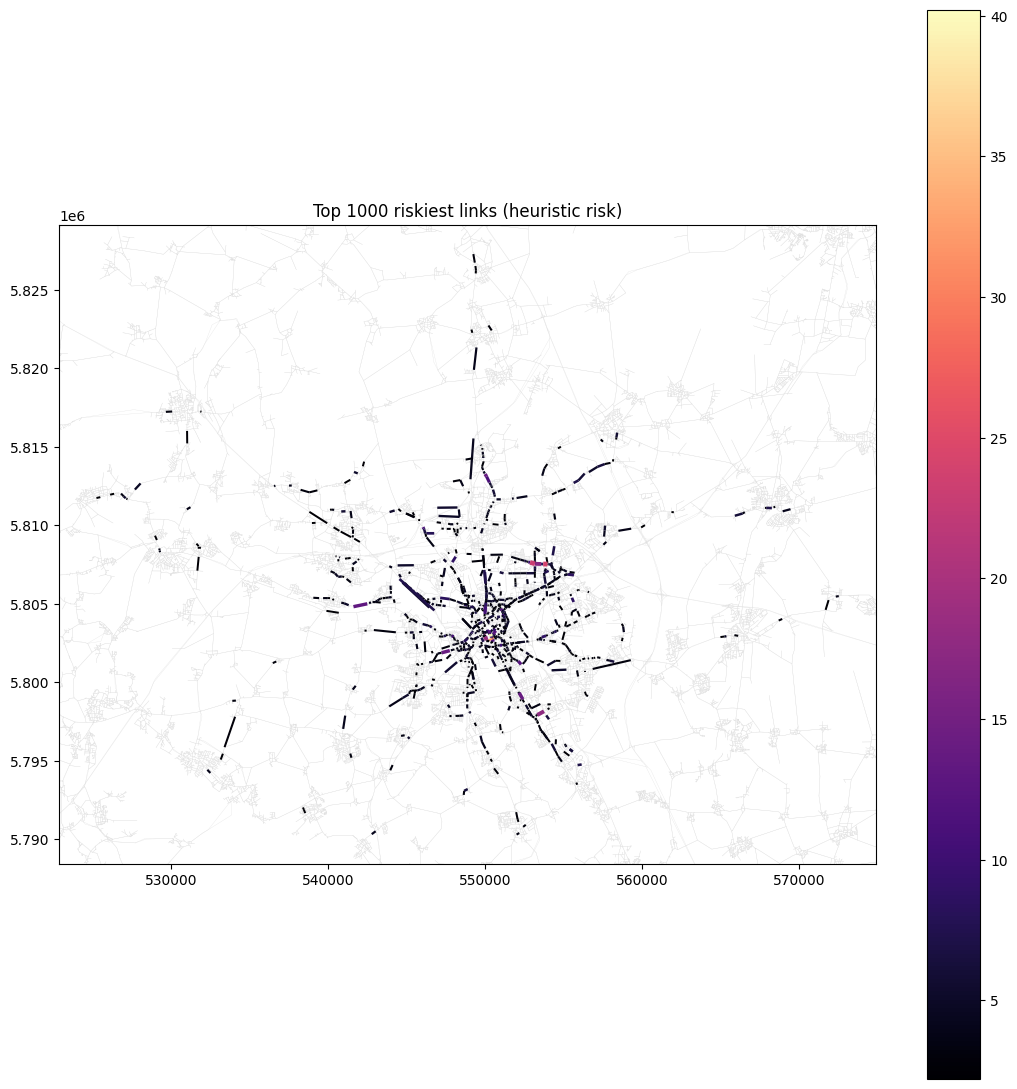

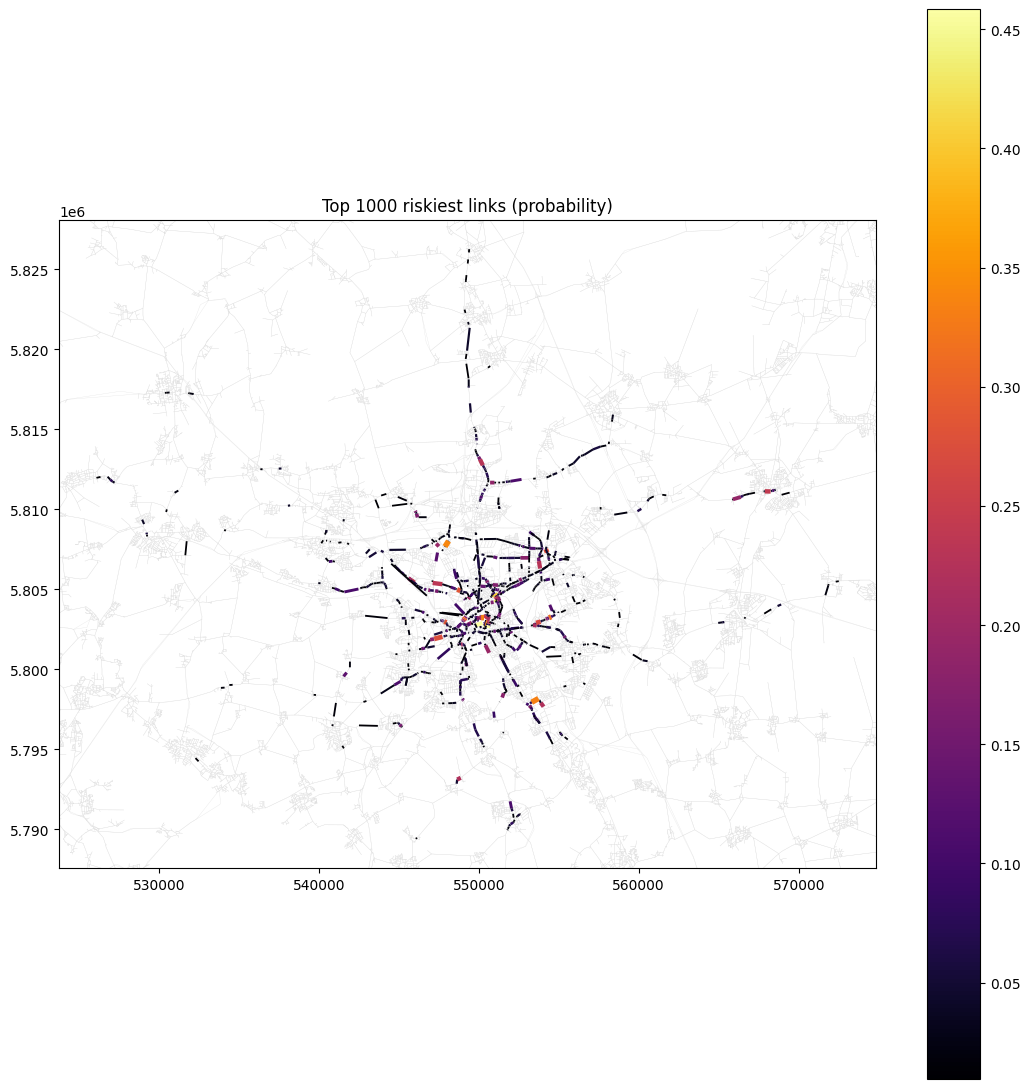

In [60]:
# 4b) Highlight top-100 riskiest links (heuristic and probability)
TOP_K = 1000

# Ensure peak frames exist
if 'peak_risk' not in globals():
    peak_risk = (
        risk.groupby('link_id', as_index=False)['risk_score'].max()
        .rename(columns={'risk_score':'risk_peak'})
    )
if 'risk_peak_prob' not in globals():
    risk_peak_prob = risk.groupby('link_id', as_index=False)['p_second_row'].max()

# Filter to links with at least one LMD stop during the day, if available
def filter_lmd(df):
    if 'LMD_LINKS_DAY' in globals() and LMD_LINKS_DAY:
        return df[df['link_id'].isin(LMD_LINKS_DAY)]
    return df

# Top-K by heuristic risk
risk_topk = filter_lmd(peak_risk).nlargest(TOP_K, 'risk_peak')
risk_topk_map = geo_links.merge(risk_topk, on='link_id', how='inner')
plot_weighted_lines(
    geo_links, risk_topk_map, 'risk_peak', cmap='magma',
    min_lw=1.2, max_lw=5.0, figsize=(11,11),
    title=f'Top {TOP_K} riskiest links (heuristic risk)', legend=True,
    crop_to_overlay=True, buffer_ratio=0.05,
)
plt.tight_layout()

# Top-K by probability
prob_topk = filter_lmd(risk_peak_prob).nlargest(TOP_K, 'p_second_row')
prob_topk_map = geo_links.merge(prob_topk, on='link_id', how='inner')
plot_weighted_lines(
    geo_links, prob_topk_map, 'p_second_row', cmap='inferno',
    min_lw=1.2, max_lw=5.0, figsize=(11,11),
    title=f'Top {TOP_K} riskiest links (probability)', legend=True,
    crop_to_overlay=True, buffer_ratio=0.05,
)
plt.tight_layout()

Sensitivity plots created. Adjust stops_per_hour, avg_dwell_s, B_def, U0_def, ALPHA_def, LANE_ALPHA_def as needed.


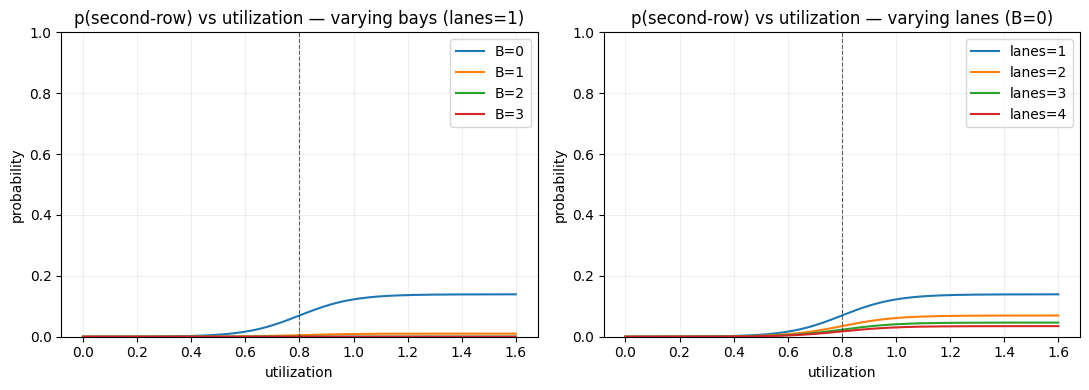

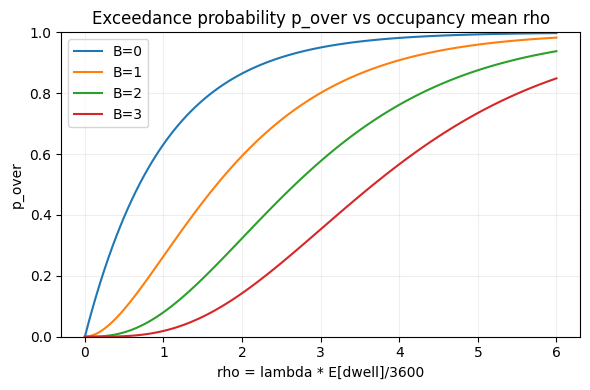

In [61]:
# 5) Parameter sensitivity: theoretical probability curves
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Use current notebook defaults if available
U0_def = globals().get('U0', 0.8)
ALPHA_def = globals().get('ALPHA', 10.0)
LANE_ALPHA_def = globals().get('LANE_ALPHA', 1.0)
B_def = globals().get('B_BAYS_DEFAULT', 0)


def p_second_row_prob(util, stops_per_hour, dwell_avg_s,
                      B=B_def, lanes=1,
                      U0=U0_def, ALPHA=ALPHA_def, LANE_ALPHA=LANE_ALPHA_def):
    """Theoretical probability of second-row issue for given parameters.
    util: utilization (0..~2)
    stops_per_hour: expected stops per hour on the link
    dwell_avg_s: average dwell time in seconds
    B: number of legal loading bays available
    lanes: number of lanes on the link
    U0, ALPHA: logistic parameters for traffic pressure
    LANE_ALPHA: exponent for lane reduction factor (1/lanes^LANE_ALPHA)
    """
    util = np.asarray(util, dtype=float)
    rho = (float(stops_per_hour) * float(dwell_avg_s)) / 3600.0  # Poisson mean of concurrent occupancy
    p_over = 1.0 - poisson.cdf(int(B), rho)                      # exceedance of legal bays
    p_traffic = 1.0 / (1.0 + np.exp(-float(ALPHA) * (util - float(U0))))
    lane_factor = 1.0 / np.power(float(lanes), float(LANE_ALPHA))
    return np.clip(p_over * p_traffic * lane_factor, 0.0, 1.0)

# Sweep ranges
utils = np.linspace(0.0, 1.6, 161)
# Fix an activity profile (tweak as desired)
stops_per_hour = 3.0
avg_dwell_s = 180.0

# Figure 1: p vs utilization for different B (lanes fixed)
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
for B in [0, 1, 2, 3]:
    y = p_second_row_prob(utils, stops_per_hour, avg_dwell_s, B=B, lanes=1)
    plt.plot(utils, y, label=f'B={B}')
plt.axvline(U0_def, color='k', linestyle='--', linewidth=0.8, alpha=0.6)
plt.title('p(second-row) vs utilization — varying bays (lanes=1)')
plt.xlabel('utilization')
plt.ylabel('probability')
plt.ylim(0, 1)
plt.grid(True, alpha=0.2)
plt.legend()

# Figure 1 (right): p vs utilization for different lanes (B fixed)
plt.subplot(1, 2, 2)
for lanes in [1, 2, 3, 4]:
    y = p_second_row_prob(utils, stops_per_hour, avg_dwell_s, B=B_def, lanes=lanes)
    plt.plot(utils, y, label=f'lanes={lanes}')
plt.axvline(U0_def, color='k', linestyle='--', linewidth=0.8, alpha=0.6)
plt.title(f'p(second-row) vs utilization — varying lanes (B={B_def})')
plt.xlabel('utilization')
plt.ylabel('probability')
plt.ylim(0, 1)
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()

# Figure 2: Occupancy exceedance only (p_over) vs rho for different B
rhos = np.linspace(0.0, 6.0, 121)
plt.figure(figsize=(6, 4))
for B in [0, 1, 2, 3]:
    p_over = 1.0 - poisson.cdf(B, rhos)
    plt.plot(rhos, p_over, label=f'B={B}')
plt.title('Exceedance probability p_over vs occupancy mean rho')
plt.xlabel('rho = lambda * E[dwell]/3600')
plt.ylabel('p_over')
plt.ylim(0, 1)
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()

print('Sensitivity plots created. Adjust stops_per_hour, avg_dwell_s, B_def, U0_def, ALPHA_def, LANE_ALPHA_def as needed.')

,link_id,util_peak,stops_day,dwell_avg_s,length,permlanes,stops_per_m,is_one_lane,simple_score
19251,139390,0.583333,7.0,2755.600000,94.015167,1.0,0.074456,True,0.442377
103120,3189667-2599015,0.566667,7.0,4158.500000,136.869227,1.0,0.051144,True,0.430712
32117,1662108-1931800-2908221,0.633333,7.0,2376.250000,91.980291,1.0,0.076103,True,0.429973
117068,3487810,0.730000,7.0,1719.083333,90.330499,1.0,0.077493,True,0.380732
32118,1662117-3675708,0.416667,7.0,5956.937500,172.681681,1.0,0.040537,True,0.352274
146772,698990,0.983333,4.0,985.166667,52.646348,1.0,0.075979,True,0.320059
94403,3009151,1.133333,7.0,435.000000,71.716422,1.0,0.097607,True,0.271021
103745,3203496,0.650000,7.0,1060.000000,85.111283,1.0,0.082245,True,0.242349
109502,331981,0.833333,5.0,659.000000,56.076869,1.0,0.089163,True,0.237521
90098,2912552-2912554,0.833333,7.0,2794.400000,259.236612,1.0,0.027002,True,0.232100


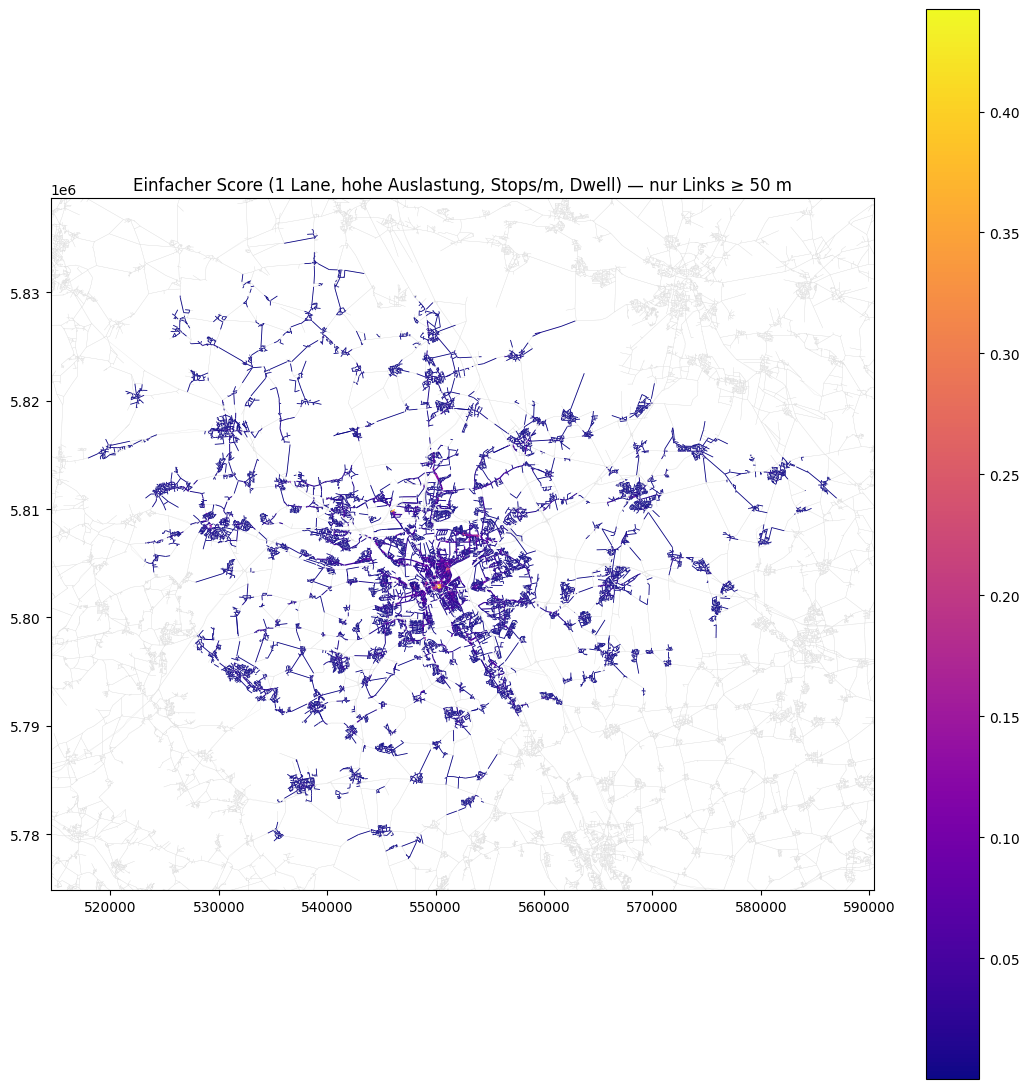

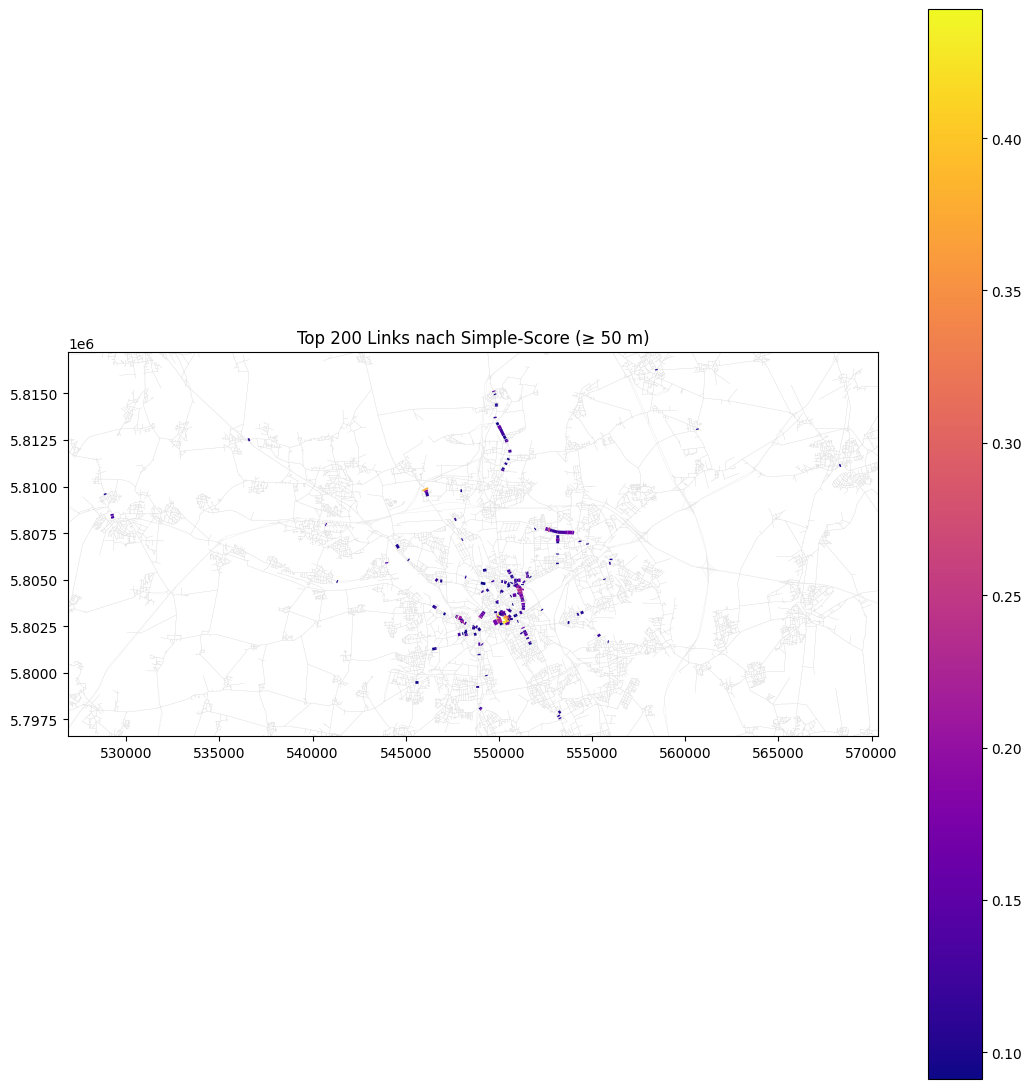

In [64]:
# 6) Einfacher Score: hohe Auslastung, 1 Lane, viele Stops pro Meter, lange Dwell
import numpy as np
import pandas as pd

# Mindestlänge nur hier in der Score-Berechnung anwenden
LENGTH_MIN_METERS = 50.0

# 1) Peak-Utilization pro Link
util_peak = (
    hourly.groupby('link_id', as_index=False)['utilization']
    .max()
    .rename(columns={'utilization': 'util_peak'})
)

# 2) Stops und Dwell auf Tagesebene pro Link aggregieren
stops_day = (
    link_hour_stops.groupby('link_id', as_index=False)
    .agg(stops_day=('stops', 'sum'), dwell_avg_s=('dwell_avg_s', 'mean'))
)

# 3) Längen- und Lane-Infos holen
lengths = net.links[['link_id', 'length']].copy()
lane_col_src = None
for c in ['permlanes', 'lanes', 'num_lanes']:
    if c in net.links.columns:
        lane_col_src = c
        break
if lane_col_src is None:
    lengths['lanes'] = 1.0
    lane_col_src = 'lanes'
else:
    lengths = lengths.merge(net.links[['link_id', lane_col_src]], on='link_id', how='left')

lengths['link_id'] = lengths['link_id'].astype(str)
lengths['length'] = pd.to_numeric(lengths['length'], errors='coerce')
lengths['length'] = lengths['length'].fillna(lengths['length'].median())
lengths[lane_col_src] = pd.to_numeric(lengths[lane_col_src], errors='coerce').fillna(1.0)

# Nur Links >= 50 m für Score berücksichtigen
lengths = lengths[lengths['length'] >= LENGTH_MIN_METERS].copy()

# 4) Merge alles zusammen
score_df = (
    util_peak.merge(stops_day, on='link_id', how='left')
             .merge(lengths, on='link_id', how='inner')  # inner join => nur Links mit bekannter Länge >= 50 m
)
score_df[['stops_day', 'dwell_avg_s']] = score_df[['stops_day', 'dwell_avg_s']].fillna(0)

# 5) Stops pro Meter (robust)
score_df['stops_per_m'] = score_df['stops_day'] / score_df['length'].clip(lower=LENGTH_MIN_METERS)

# 6) 1-Lane-Filter: Score nur für Einspurige (streng == 1); sonst 0
score_df['is_one_lane'] = (score_df[lane_col_src].round(0) == 1)

# 7) Einfacher Score: util_peak × stops_per_m × (1 + dwell_avg_s / 300)
score_df['simple_score'] = 0.0
mask1 = score_df['is_one_lane'] & score_df['util_peak'].notna()
score_df.loc[mask1, 'simple_score'] = (
    score_df.loc[mask1, 'util_peak'].clip(0, 2.0)
    * score_df.loc[mask1, 'stops_per_m']
    * (1.0 + score_df.loc[mask1, 'dwell_avg_s'] / 300.0)
)

# 8) Karte und Top-K
simple_map = geo_links.merge(score_df[['link_id', 'simple_score']], on='link_id', how='inner')
simple_map['simple_score'] = simple_map['simple_score'].fillna(0)

plot_weighted_lines(
    geo_links, simple_map, 'simple_score', cmap='plasma',
    min_lw=0.6, max_lw=4.0, figsize=(11,11),
    title='Einfacher Score (1 Lane, hohe Auslastung, Stops/m, Dwell) — nur Links ≥ 50 m', legend=True,
    crop_to_overlay=True, buffer_ratio=0.05,
)
plt.tight_layout()

# Top-K
TOP_K_SIMPLE = 200
simple_topk = score_df.nlargest(TOP_K_SIMPLE, 'simple_score')
simple_topk_map = geo_links.merge(simple_topk[['link_id', 'simple_score']], on='link_id', how='inner')
plot_weighted_lines(
    geo_links, simple_topk_map, 'simple_score', cmap='plasma',
    min_lw=1.2, max_lw=5.0, figsize=(11,11),
    title=f'Top {TOP_K_SIMPLE} Links nach Simple-Score (≥ 50 m)', legend=True,
    crop_to_overlay=True, buffer_ratio=0.05,
)
plt.tight_layout()

# Ausgabe der Top 15
score_df.sort_values('simple_score', ascending=False).head(15)

,link_id,util_peak,stops_day,dwell_avg_s,length,permlanes,stops_per_m,is_one_lane,simple_score
19251,139390,0.583333,7.0,2755.600000,94.015167,1.0,0.074456,True,0.442377
103120,3189667-2599015,0.566667,7.0,4158.500000,136.869227,1.0,0.051144,True,0.430712
32117,1662108-1931800-2908221,0.633333,7.0,2376.250000,91.980291,1.0,0.076103,True,0.429973
117068,3487810,0.730000,7.0,1719.083333,90.330499,1.0,0.077493,True,0.380732
32118,1662117-3675708,0.416667,7.0,5956.937500,172.681681,1.0,0.040537,True,0.352274
146772,698990,0.983333,4.0,985.166667,52.646348,1.0,0.075979,True,0.320059
94403,3009151,1.133333,7.0,435.000000,71.716422,1.0,0.097607,True,0.271021
103745,3203496,0.650000,7.0,1060.000000,85.111283,1.0,0.082245,True,0.242349
109502,331981,0.833333,5.0,659.000000,56.076869,1.0,0.089163,True,0.237521
90098,2912552-2912554,0.833333,7.0,2794.400000,259.236612,1.0,0.027002,True,0.232100


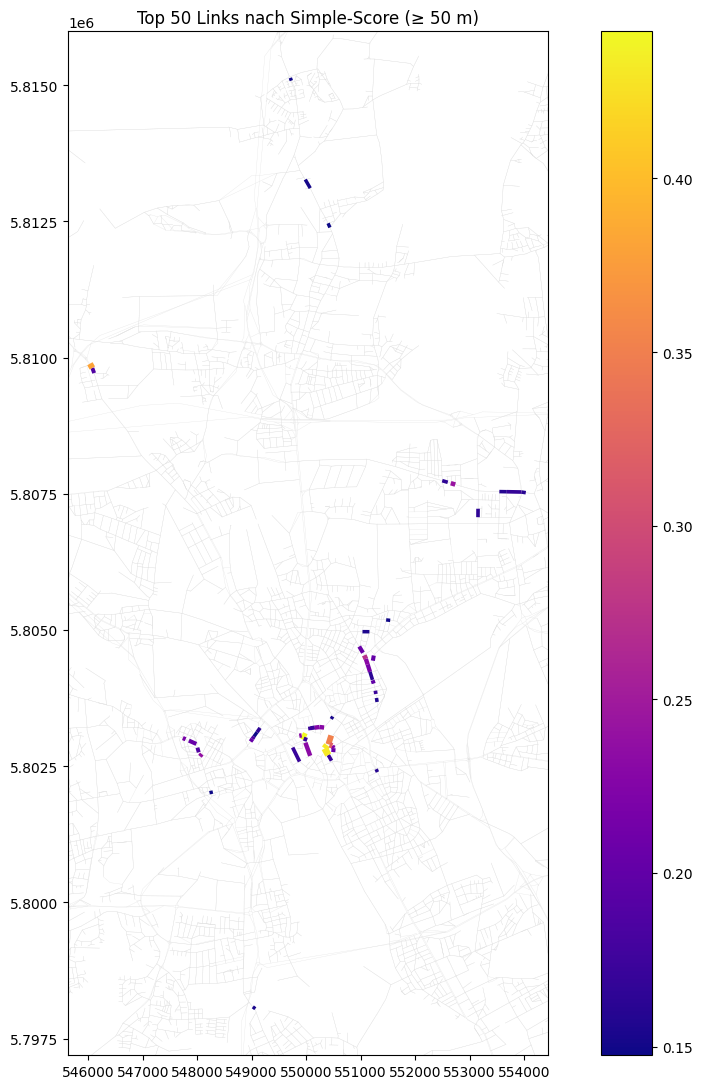

In [66]:
# Top-K
TOP_K_SIMPLE = 50
simple_topk = score_df.nlargest(TOP_K_SIMPLE, 'simple_score')
simple_topk_map = geo_links.merge(simple_topk[['link_id', 'simple_score']], on='link_id', how='inner')
plot_weighted_lines(
    geo_links, simple_topk_map, 'simple_score', cmap='plasma',
    min_lw=1.2, max_lw=5.0, figsize=(11,11),
    title=f'Top {TOP_K_SIMPLE} Links nach Simple-Score (≥ 50 m)', legend=True,
    crop_to_overlay=True, buffer_ratio=0.05,
)
plt.tight_layout()

# Ausgabe der Top 15
score_df.sort_values('simple_score', ascending=False).head(15)